### Analysis on a tomato callus dataset (10x data) ###

In [1]:
import os
import re
import anndata as ad
import pandas as pd
import scanpy as sc
import numpy as np
import scipy.sparse as sp
from kneed import KneeLocator
import matplotlib.pyplot as plt
from collections import defaultdict, deque
from gei_nj import comb_depth_ratio, filt_snv_by_depth_ratio, add_callable_layer, revise_snv_ratio, impute_non_callable_by_snv_mean, build_and_plot_nj, comb_depth_ratio, plot_snv_pca_by_group

Set colors of branches

In [2]:
group_colors_ct = {'Inner_callus':'#E27C80', 'Outgrowth_shoot':'#9ACE8F', 'Vascular_tissue':'#F4BE76', 'Epidermis':'#6ECACD', 'Shoot_primordia':'#906A4A'}
group_colors_cmb = {"Inner_callus_cmb_0":"#B850B1", "Inner_callus_cmb_1":"#CD6698", "Inner_callus_cmb_2":"#E27C80", "Inner_callus_cmb_3":"#D16144",
                     "Outgrowth_shoot_cmb_0":"#357B6E", "Outgrowth_shoot_cmb_1":"#469B80", "Outgrowth_shoot_cmb_2":"#68B78B", "Outgrowth_shoot_cmb_3":"#9ACE8F", "Outgrowth_shoot_cmb_4":"#357B3B", 
                     "Vascular_tissue_cmb_0":"#FFDBB0", "Vascular_tissue_cmb_1":"#f0bd78", "Vascular_tissue_cmb_2":"#F5CD1E", "Vascular_tissue_cmb_3":"#F29651",
                     "Epidermis_cmb_0":"#46466A", "Epidermis_cmb_1":"#4FA9B2", "Epidermis_cmb_2":"#5691AC", "Epidermis_cmb_3":"#84CDD3",
                     "Shoot_primordia_cmb_0":"#82543A", "Shoot_primordia_cmb_1":"#A88764", "Shoot_primordia_cmb_2":"#d1c392", "Shoot_primordia_cmb_3":"#B7B6B3", "Shoot_primordia_cmb_4":"#857b5d", "Shoot_primordia_cmb_5":"#9aa65b"}

Process data

In [3]:
## Load in SNV ratio and depth of a dataset
ad_ratio = ad.read_h5ad("../../02.Tomato_callus/data/10x_data/10x_CMBlevel/unit_ratio.h5ad")
ad_depth = ad.read_h5ad("../../02.Tomato_callus/data/10x_data/10x_CMBlevel/unit_depth.h5ad")

## Combine depth and ratio to a combined adata
adata = comb_depth_ratio(ad_depth, ad_ratio)

## Filter SNVs based on depth and ratio
adata = filt_snv_by_depth_ratio(adata, min_tot_depth=20, min_mut_depth=5, min_mut_avg_ratio=0.1)

SNV number before filter: 98563
SNV number after filter: 21708


Construct callable layer based on depth

In [4]:
adata = add_callable_layer(adata, min_callable_depth=3)

Callable layer added to adata.layers['callable']
Minimum callable depth: 3
Total SNV entries: 499284
Callable SNV entries: 276855
Global callable fraction: 0.5545


In [5]:
## Check if 'callable' layer is added
adata

AnnData object with n_obs × n_vars = 23 × 21708
    layers: 'depth', 'callable'

In [6]:
## change SNV ratio (adata.X) to 0, 0.5 and 1. By default, the original SNV ratio will be moved to the 'original_ratio' layer.
adata = revise_snv_ratio(adata) 

In [7]:
adata

AnnData object with n_obs × n_vars = 23 × 21708
    layers: 'depth', 'callable', 'original_ratio'

In [8]:
## Remove SNVs that are not callable in all units
C = adata.layers["callable"]

if sp.issparse(C):
    n_callable_cmb_per_snv = np.asarray(C.sum(axis=0)).ravel()
else:
    n_callable_cmb_per_snv = np.asarray(C).sum(axis=0)

keep_snv = n_callable_cmb_per_snv > 0

adata = adata[:, keep_snv].copy()

print(f"SNVs kept after removing zero-callable SNVs: {adata.n_vars}")
print(f"SNVs removed: {(~keep_snv).sum()}")

SNVs kept after removing zero-callable SNVs: 21704
SNVs removed: 4


In [9]:
adata = impute_non_callable_by_snv_mean(adata, callable_layer="callable", output_layer="geinj_state_imputed",)

Non-callable entries imputed by per-SNV callable mean
Callable entries: 276855
Non-callable entries: 222337
Total SNV entries: 499192
Imputed matrix stored in adata.layers['geinj_state_imputed']
adata.X was updated to the imputed matrix


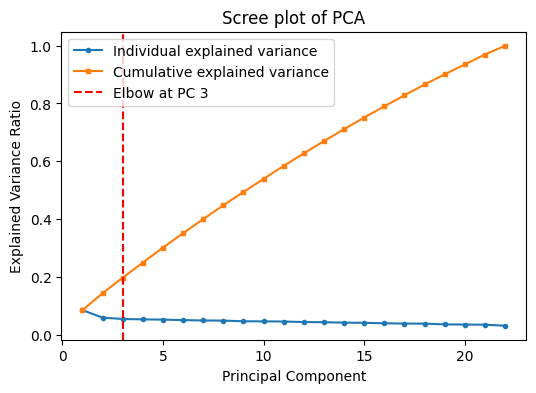

In [10]:
n_comps = min(adata.n_obs-1, adata.n_vars, 50)
sc.pp.pca(adata, n_comps=n_comps)
explained_var = adata.uns['pca']['variance_ratio']
explained_var_cum = explained_var.cumsum()

# Detect elbow point
kl = KneeLocator(range(1, len(explained_var)+1), explained_var, curve="convex", direction="decreasing")
elbow_PC = kl.elbow

adata.obs["group"] = adata.obs_names.astype(str).str.replace(r"_cmb.*$", "", regex=True)
adata.obs["group_cmb"] = adata.obs_names.astype(str)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_var)+1), explained_var, 'o-', markersize=3, label="Individual explained variance")
plt.plot(range(1, len(explained_var)+1), explained_var_cum, 's-', markersize=3, label="Cumulative explained variance")
plt.axvline(elbow_PC, color='r', linestyle='--', label=f'Elbow at PC {elbow_PC}')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.title('Scree plot of PCA')
#plt.savefig("TomatoCallus_newv2_PC_elbow_plot.pdf", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

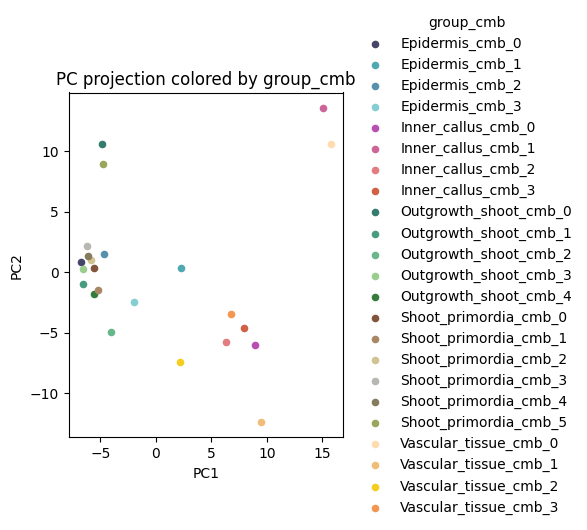

In [11]:
plot_snv_pca_by_group(adata, pcx=1, pcy=2, alpha=1, group_by="group_cmb", group_colors=group_colors_cmb, size=20,)
                     #savepath="TomatoCallus_newv2_PC1_PC2.pdf")

Plot NJ trees and color branches
PCA based GEI-NJ tree constructed from imputed revised expressed SNV states.

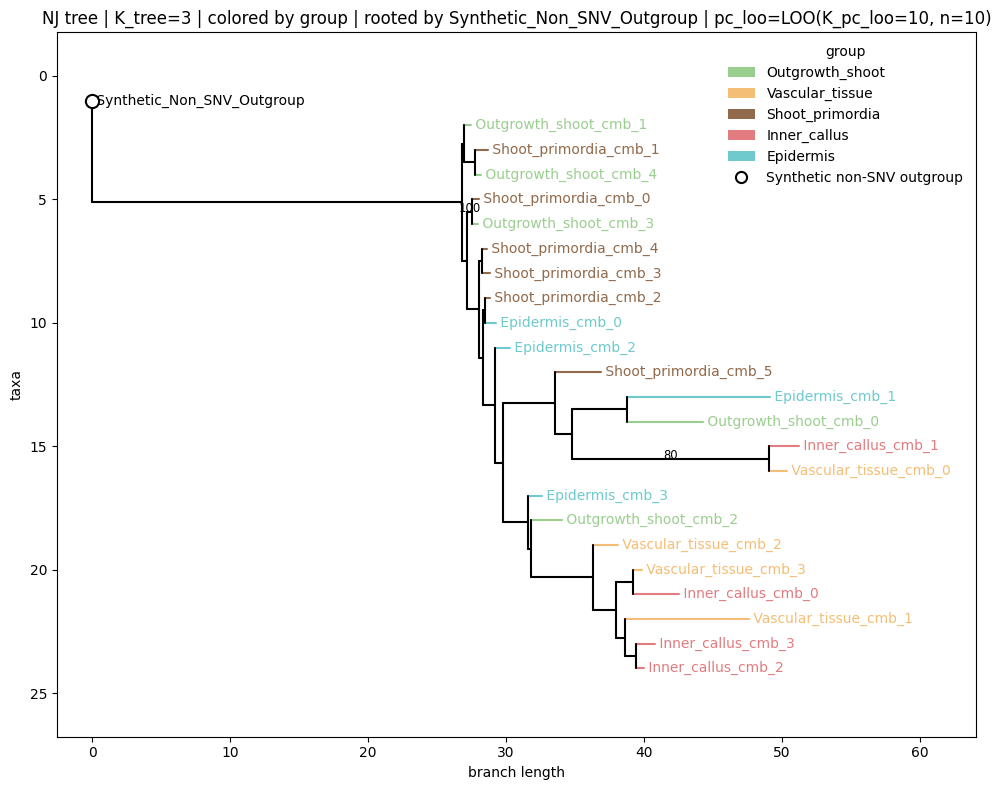

In [12]:
tree1 = build_and_plot_nj(adata, figsize=(10, 8), pc_loo=True, K_tree=3, K_pc_loo=10, 
                          pc_loo_min_support=80, group_key="group", #savepath="TomatoCallus_newv2__NJtree.pdf",
                          group_colors=group_colors_ct, show_leaf_labels=True, show_legend=True)

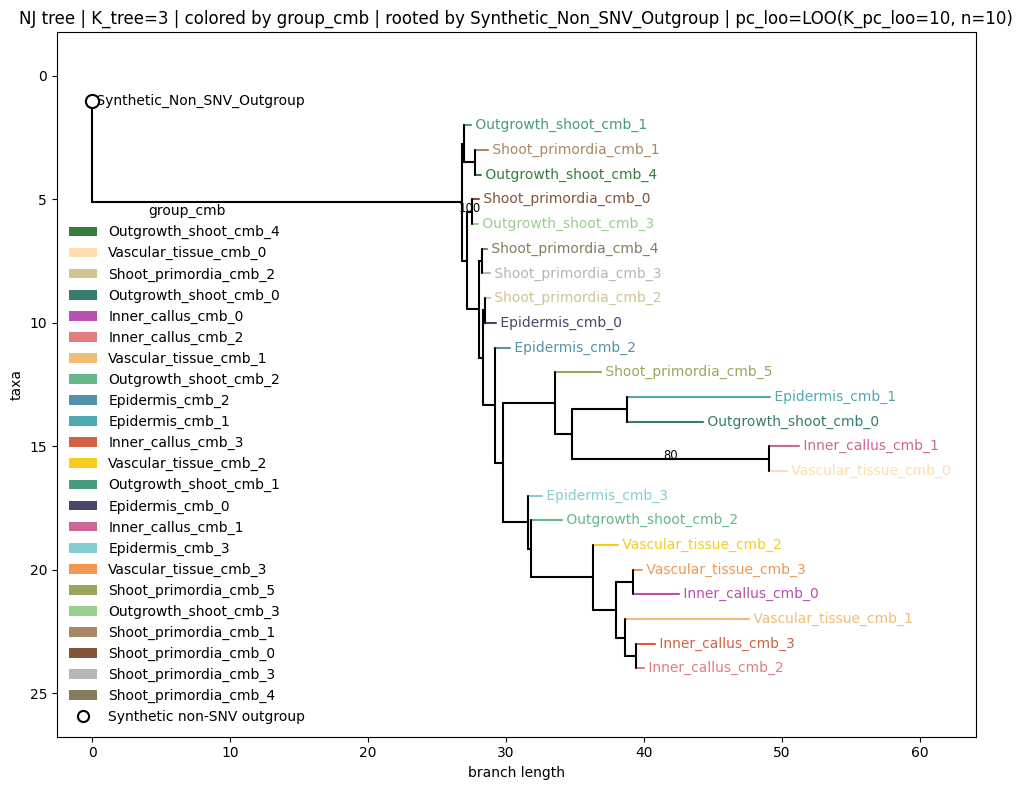

In [13]:
tree2 = build_and_plot_nj(adata, figsize=(10, 8), pc_loo=True, K_tree=3, K_pc_loo=10, 
                          pc_loo_min_support=80, group_key="group_cmb", #savepath="TomatoCallus_newv2_byCMB_NJtree.pdf",
                          group_colors=group_colors_cmb, show_leaf_labels=True, show_legend=True)